In [2]:
# PHASE 2 CLEANING - CELL 1
# Purpose:
# Set paths and verify required folders/files exist.

from pathlib import Path
import pandas as pd
import numpy as np
import re
import os
import random

PROJECT_ROOT = Path.cwd().parent

CLEAN_DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "clean_dataset.csv"
AUDIO_ROOT = PROJECT_ROOT / "data" / "raw_playlist_songs_downloaded"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Clean dataset exists:", CLEAN_DATASET_PATH.exists())
print("Audio root exists:", AUDIO_ROOT.exists())
print("Processed dir exists:", PROCESSED_DIR.exists())

if not CLEAN_DATASET_PATH.exists():
  raise FileNotFoundError(CLEAN_DATASET_PATH)

if not AUDIO_ROOT.exists():
  raise FileNotFoundError(AUDIO_ROOT)

Project root: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system
Clean dataset exists: True
Audio root exists: True
Processed dir exists: True


In [3]:

  # PHASE 2 CLEANING - CELL 2
  # Purpose:
  # Build an index of all downloaded MP3 files.
  # We parse region/category/playlist from folder structure and position/title from filename.

  def parse_audio_filename(file_path):
      stem = file_path.stem.strip()

      # Expected examples:
      # "1. Zinda"
      # "99. falling star lullaby"
      match = re.match(r"^\s*(\d+)\.\s*(.+)$", stem)

      if match:
          downloaded_position = int(match.group(1))
          downloaded_title = match.group(2).strip()
      else:
          downloaded_position = np.nan
          downloaded_title = stem

      return downloaded_position, downloaded_title

  audio_rows = []

  for file_path in AUDIO_ROOT.rglob("*.mp3"):
      relative_parts = file_path.relative_to(AUDIO_ROOT).parts

      if len(relative_parts) < 4:
          # Expected: region/category/playlist/file.mp3
          continue

      region = relative_parts[0]
      category = relative_parts[1]
      playlist_name = relative_parts[2]

      downloaded_position, downloaded_title = parse_audio_filename(file_path)

      audio_rows.append({
          "audio_path": str(file_path),
          "audio_relative_path": str(file_path.relative_to(PROJECT_ROOT)),
          "region": region,
          "category": category,
          "downloaded_playlist_name": playlist_name,
          "downloaded_position": downloaded_position,
          "downloaded_title": downloaded_title,
          "filename": file_path.name
      })

  audio_index = pd.DataFrame(audio_rows)

  audio_index = audio_index.sort_values(
      ["region", "category", "downloaded_playlist_name", "downloaded_position", "downloaded_title"],
      na_position="last"
  ).reset_index(drop=True)

  audio_index_path = PROCESSED_DIR / "phase2_audio_file_index.csv"
  audio_index.to_csv(audio_index_path, index=False)

  print("Audio files indexed:", len(audio_index))
  print("Saved:", audio_index_path)

  display(audio_index.head(20))

Audio files indexed: 2426
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_audio_file_index.csv


,audio_path,audio_relative_path,region,category,downloaded_playlist_name,downloaded_position,downloaded_title,filename
0,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,1,Raabta,1. Raabta.mp3
1,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,2,Tum Se Hi,2. Tum Se Hi.mp3
2,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,3,Le Aaunga (From _Satyaprem Ki Katha_),3. Le Aaunga (From _Satyaprem Ki Katha_).mp3
3,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,4,Agar Ho Tum (From _Mr. And Mrs. Mahi_),4. Agar Ho Tum (From _Mr. And Mrs. Mahi_).mp3
4,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,5,Ek Din Title Track - From _Ek Din_,5. Ek Din Title Track - From _Ek Din_.mp3
5,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,6,Dil Jhoom,6. Dil Jhoom.mp3
6,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,7,Kesariya (From _Brahmastra_),7. Kesariya (From _Brahmastra_).mp3
7,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,8,Koi Naa (From _Bhool Chuk Maaf_),8. Koi Naa (From _Bhool Chuk Maaf_).mp3
8,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,9,Tere Bina,9. Tere Bina.mp3
9,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...,hindi,chill_lyrics,Peaceful & Soft Hindi Songs,10,Sajni (From _Laapataa Ladies_),10. Sajni (From _Laapataa Ladies_).mp3


In [8]:
# PHASE 2 CLEANING - CELL 3
# Purpose:
# Load the Phase 1 clean dataset and prepare normalized title fields for fuzzy matching.

df_clean = pd.read_csv(CLEAN_DATASET_PATH)

print("Clean dataset rows:", len(df_clean))
print("Clean dataset playlists:", df_clean["pid"].nunique())
print("Columns:")
print(df_clean.columns.tolist())

def normalize_title(text):
  if pd.isna(text):
      return ""

  text = str(text).lower()

  # Replace common separators/artifacts.
  text = text.replace("_", " ")
  text = text.replace("-", " ")
  text = text.replace("&", " and ")

  # Remove bracketed version info often found in filenames.
  text = re.sub(r"\([^)]*\)", " ", text)
  text = re.sub(r"\[[^\]]*\]", " ", text)

  # Remove common music-version words that make matching noisy.
  noise_words = [
      "from", "lofi", "lo fi", "slowed", "reverb", "reverbed",
      "remix", "mix", "version", "feat", "ft", "original",
      "official", "audio", "video", "lyrics"
  ]

  for word in noise_words:
      text = re.sub(rf"\b{re.escape(word)}\b", " ", text)

  # Keep only alphanumeric text.
  text = re.sub(r"[^a-z0-9\s]", " ", text)
  text = re.sub(r"\s+", " ", text).strip()

  return text

df_clean["normalized_track_name"] = df_clean["Track Name"].apply(normalize_title)
audio_index["normalized_downloaded_title"] = audio_index["downloaded_title"].apply(normalize_title)

# Make region_genre_id comparable with downloaded folder region/category.
audio_index["downloaded_region_genre_id"] = audio_index["region"] + "_" +audio_index["category"]

print("\nDownloaded region/category counts:")
display(audio_index["downloaded_region_genre_id"].value_counts().reset_index())

print("\nClean dataset region/category counts:")
display(df_clean["region_genre_id"].value_counts().reset_index())

print("\nSample normalized CSV titles:")
display(df_clean[["Track Name", "normalized_track_name", "region_genre_id", "pid",
"position"]].head(10))

print("\nSample normalized downloaded titles:")
display(audio_index[["downloaded_title", "normalized_downloaded_title",
"downloaded_region_genre_id", "downloaded_playlist_name",
"downloaded_position"]].head(10))

Clean dataset rows: 3576
Clean dataset playlists: 29
Columns:
['Track URI', 'Track Name', 'Artist Name(s)', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'pid', 'region_genre_id', 'track_id', 'position', 'pid_position']

Downloaded region/category counts:


,downloaded_region_genre_id,count
0,western_focus,420
1,western_chill_lyrics,346
2,western_sleep,294
3,western_dj,275
4,telugu_sleep,251
5,hindi_study,231
6,hindi_chill_lyrics,216
7,hindi_sleep,206
8,telugu_chill_lyrics,187



Clean dataset region/category counts:


,region_genre_id,count
0,western_focus,1031
1,western_sleep,545
2,western_dj,399
3,western_chill_lyrics,384
4,hindi_chill_lyrics,300
5,hindi_study,300
6,hindi_sleep,272
7,telugu_chill_lyrics,245
8,telugu_sleep,100



Sample normalized CSV titles:


,Track Name,normalized_track_name,region_genre_id,pid,position
0,Zinda,zinda,hindi_chill_lyrics,1,1
1,Sultan,sultan,hindi_chill_lyrics,1,2
2,Dangal,dangal,hindi_chill_lyrics,1,3
3,"Kar Har Maidaan Fateh (From ""Sanju"")",kar har maidaan fateh,hindi_chill_lyrics,1,4
4,Brothers Anthem,brothers anthem,hindi_chill_lyrics,1,5
5,Jai Ho,jai ho,hindi_chill_lyrics,1,6
6,Jee Karda (Rock Version),jee karda,hindi_chill_lyrics,1,7
7,Saadda Haq,saadda haq,hindi_chill_lyrics,1,8
8,Soorma Anthem,soorma anthem,hindi_chill_lyrics,1,9
9,Raftaarein,raftaarein,hindi_chill_lyrics,1,10



Sample normalized downloaded titles:


,downloaded_title,normalized_downloaded_title,downloaded_region_genre_id,downloaded_playlist_name,downloaded_position
0,Raabta,raabta,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,1
1,Tum Se Hi,tum se hi,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,2
2,Le Aaunga (From _Satyaprem Ki Katha_),le aaunga,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,3
3,Agar Ho Tum (From _Mr. And Mrs. Mahi_),agar ho tum,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,4
4,Ek Din Title Track - From _Ek Din_,ek din title track ek din,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,5
5,Dil Jhoom,dil jhoom,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,6
6,Kesariya (From _Brahmastra_),kesariya,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,7
7,Koi Naa (From _Bhool Chuk Maaf_),koi naa,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,8
8,Tere Bina,tere bina,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,9
9,Sajni (From _Laapataa Ladies_),sajni,hindi_chill_lyrics,Peaceful & Soft Hindi Songs,10


In [11]:
# PHASE 2 CLEANING - CELL 4A
# Purpose:
# Install/import rapidfuzz for title matching.

try:
  from rapidfuzz import process, fuzz
  print("rapidfuzz already available")
except ImportError:
  %pip install rapidfuzz
  from rapidfuzz import process, fuzz
  print("rapidfuzz installed and imported")



   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 6.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
rapidfuzz installed and imported


In [13]:


# PHASE 2 CLEANING - CELL 4B
# Purpose:
# Fuzzy-match CSV songs to downloaded MP3 files.
# CSV remains the authority for pid/position/order.
# We attach audio_path where the downloaded title is a confident match.

MATCH_THRESHOLD = 88

matched_rows = []

# Build candidates by downloaded region/category.
audio_by_group = {
  group: group_df.reset_index(drop=True)
  for group, group_df in audio_index.groupby("downloaded_region_genre_id")
}

for idx, row in df_clean.iterrows():
  group = row["region_genre_id"]
  query = row["normalized_track_name"]

  if group not in audio_by_group or not query:
      matched_rows.append({
          "clean_index": idx,
          "match_status": "no_group",
          "match_score": 0,
          "audio_index": np.nan,
          "audio_path": np.nan,
          "audio_relative_path": np.nan,
          "downloaded_title": np.nan,
          "downloaded_playlist_name": np.nan,
          "downloaded_position": np.nan,
      })
      continue

  candidates_df = audio_by_group[group]
  choices = candidates_df["normalized_downloaded_title"].tolist()

  best = process.extractOne(
      query,
      choices,
      scorer=fuzz.token_set_ratio
  )

  if best is None:
      matched_rows.append({
          "clean_index": idx,
          "match_status": "no_match",
          "match_score": 0,
          "audio_index": np.nan,
          "audio_path": np.nan,
          "audio_relative_path": np.nan,
          "downloaded_title": np.nan,
          "downloaded_playlist_name": np.nan,
          "downloaded_position": np.nan,
      })
      continue

  best_title, score, candidate_pos = best
  matched_audio = candidates_df.iloc[candidate_pos]

  match_status = "matched" if score >= MATCH_THRESHOLD else "low_confidence"

  matched_rows.append({
      "clean_index": idx,
      "match_status": match_status,
      "match_score": score,
      "audio_index": candidate_pos,
      "audio_path": matched_audio["audio_path"],
      "audio_relative_path": matched_audio["audio_relative_path"],
      "downloaded_title": matched_audio["downloaded_title"],
      "downloaded_playlist_name": matched_audio["downloaded_playlist_name"],
      "downloaded_position": matched_audio["downloaded_position"],
  })

match_df = pd.DataFrame(matched_rows)

phase2_matched = df_clean.reset_index(names="clean_index").merge(
  match_df,
  on="clean_index",
  how="left"
)

match_summary =phase2_matched["match_status"].value_counts(dropna=False).reset_index()
print("Match summary:")
display(match_summary)

print("\nScore summary:")
display(phase2_matched["match_score"].describe())

print("\nHigh-confidence matches sample:")
display(
  phase2_matched.loc[
      phase2_matched["match_status"] == "matched",
      ["Track Name", "downloaded_title", "region_genre_id", "pid", "position",
"match_score", "audio_relative_path"]
  ].head(20)
)

print("\nLow-confidence sample:")
display(
  phase2_matched.loc[
      phase2_matched["match_status"] == "low_confidence",
      ["Track Name", "downloaded_title", "region_genre_id", "pid", "position",
"match_score"]
  ].head(20)
)

Match summary:


,match_status,count
0,low_confidence,1793
1,matched,1783



Score summary:


count    3576.000000
mean       79.637122
std        21.276087
min        25.000000
25%        58.823529
50%        85.714286
75%       100.000000
max       100.000000
Name: match_score, dtype: float64


High-confidence matches sample:


,Track Name,downloaded_title,region_genre_id,pid,position,match_score,audio_relative_path
0,Zinda,Zinda,hindi_chill_lyrics,1,1,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
11,Chal Utth Bandeya,Bandeya,hindi_chill_lyrics,1,12,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
29,Zinda Hai,Zinda,hindi_chill_lyrics,1,30,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
67,"Tum Se Hi (From ""Love In Lo-Fi Volume 1"")",Tum Se Hi,hindi_chill_lyrics,2,1,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
68,Subhanallah Lofi Mix,Subhanallah,hindi_chill_lyrics,2,2,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
69,Pee Loon Lofi Mix,Pee Loon,hindi_chill_lyrics,2,3,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
70,Saibo,Saibo,hindi_chill_lyrics,2,4,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
73,"Ek Din Title Track - From ""Ek Din""",Ek Din Title Track - From _Ek Din_,hindi_chill_lyrics,2,7,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
76,"Kesariya (From ""Brahmastra"")",Kesariya (From _Brahmastra_),hindi_chill_lyrics,2,10,100.0,data\raw_playlist_songs_downloaded\hindi\chill...
77,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",Agar Ho Tum (From _Mr. And Mrs. Mahi_),hindi_chill_lyrics,2,11,100.0,data\raw_playlist_songs_downloaded\hindi\chill...



Low-confidence sample:


,Track Name,downloaded_title,region_genre_id,pid,position,match_score
1,Sultan,Uljhan,hindi_chill_lyrics,1,2,66.666667
2,Dangal,Le Aaunga (From _Satyaprem Ki Katha_),hindi_chill_lyrics,1,3,66.666667
3,"Kar Har Maidaan Fateh (From ""Sanju"")",Bawara Mann (From _Jolly Ll.B 2_),hindi_chill_lyrics,1,4,50.000000
4,Brothers Anthem,Tere Naina,hindi_chill_lyrics,1,5,48.000000
5,Jai Ho,O Saathi,hindi_chill_lyrics,1,6,57.142857
6,Jee Karda (Rock Version),Jee Le Zaraa,hindi_chill_lyrics,1,7,66.666667
7,Saadda Haq,Sapna Jahan (From _Brothers_),hindi_chill_lyrics,1,8,57.142857
8,Soorma Anthem,Kasoor,hindi_chill_lyrics,1,9,52.631579
9,Raftaarein,Baarishein,hindi_chill_lyrics,1,10,60.000000
10,Bhaag Milkha Bhaag - Rock Version,Moh Moh Ke Dhaage (Male),hindi_chill_lyrics,1,11,53.333333


In [17]:
# PHASE 2 CLEANING - CELL 4C
# Purpose:
# Strict exact matching between CSV song titles and downloaded MP3 titles.
# We normalize both sides by lowercasing and removing punctuation/extra spaces.
# No fuzzy/partial matching is used.

def normalize_title_strict(text):
  if pd.isna(text):
      return ""

  text = str(text).lower()

  # Normalize separators.
  text = text.replace("_", " ")
  text = text.replace("-", " ")
  text = text.replace("&", " and ")

  # Remove common quote characters.
  text = text.replace('"', " ")
  text = text.replace("'", " ")

  # Remove punctuation/symbols but keep letters and numbers.
  text = re.sub(r"[^a-z0-9\s]", " ", text)

  # Collapse spaces.
  text = re.sub(r"\s+", " ", text).strip()

  return text

df_clean["strict_title_key"] = df_clean["Track Name"].apply(normalize_title_strict)
audio_index["strict_title_key"] =audio_index["downloaded_title"].apply(normalize_title_strict)
audio_index["downloaded_region_genre_id"] = audio_index["region"] + "_" +audio_index["category"]

# If the same title appears multiple times inside one group, keep all for diagnostics first.
candidate_audio = audio_index[
  [
      "downloaded_region_genre_id",
      "strict_title_key",
      "audio_path",
      "audio_relative_path",
      "downloaded_title",
      "downloaded_playlist_name",
      "downloaded_position",
      "filename"
  ]
].copy()

phase2_exact_matches = df_clean.reset_index(names="clean_index").merge(
  candidate_audio,
  left_on=["region_genre_id", "strict_title_key"],
  right_on=["downloaded_region_genre_id", "strict_title_key"],
  how="left"
)

phase2_exact_matches["has_audio_match"] = phase2_exact_matches["audio_path"].notna()
phase2_exact_matches["position_matches"] = (
  phase2_exact_matches["position"] == phase2_exact_matches["downloaded_position"]
)

print("CSV songs:", len(df_clean))
print("Downloaded MP3 files:", len(audio_index))
print("Rows after merge:", len(phase2_exact_matches))
print("CSV songs with at least one exact audio match:",
phase2_exact_matches.loc[phase2_exact_matches["has_audio_match"],
"clean_index"].nunique())
print("Downloaded MP3 files matched at least once:",
phase2_exact_matches.loc[phase2_exact_matches["has_audio_match"],
"audio_path"].nunique())

print("\nMatched vs unmatched CSV songs:")
display(
  phase2_exact_matches.drop_duplicates("clean_index")["has_audio_match"]
  .value_counts()
  .reset_index()
)

print("\nMatch counts by region_genre_id:")
display(
  phase2_exact_matches.drop_duplicates("clean_index")
  .groupby("region_genre_id")["has_audio_match"]
  .agg(["sum", "count"])
  .assign(match_rate=lambda x: x["sum"] / x["count"])
  .sort_values("match_rate", ascending=False)
)

print("\nSample exact matches:")
display(
  phase2_exact_matches.loc[
      phase2_exact_matches["has_audio_match"],
      [
          "Track Name",
          "downloaded_title",
          "region_genre_id",
          "pid",
          "position",
          "downloaded_position",
          "position_matches",
          "audio_relative_path"
      ]
  ].head(30)
)

print("\nSample unmatched CSV songs:")
display(
  phase2_exact_matches.loc[
      ~phase2_exact_matches["has_audio_match"],
      [
          "Track Name",
          "region_genre_id",
          "pid",
          "position",
          "strict_title_key"
      ]
  ].drop_duplicates("clean_index").head(30)
)

CSV songs: 3576
Downloaded MP3 files: 2426
Rows after merge: 3655
CSV songs with at least one exact audio match: 1542
Downloaded MP3 files matched at least once: 1501

Matched vs unmatched CSV songs:


,has_audio_match,count
0,False,2034
1,True,1542



Match counts by region_genre_id:


,sum,count,match_rate
region_genre_id,,,
hindi_study,234,300,0.780000
western_dj,280,399,0.701754
western_sleep,305,545,0.559633
western_chill_lyrics,199,384,0.518229
western_focus,415,1031,0.402522
telugu_sleep,21,100,0.210000
telugu_chill_lyrics,44,245,0.179592
hindi_chill_lyrics,43,300,0.143333
hindi_sleep,1,272,0.003676



Sample exact matches:


,Track Name,downloaded_title,region_genre_id,pid,position,downloaded_position,position_matches,audio_relative_path
0,Zinda,Zinda,hindi_chill_lyrics,1,1,75.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
70,Saibo,Saibo,hindi_chill_lyrics,2,4,15.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
73,"Ek Din Title Track - From ""Ek Din""",Ek Din Title Track - From _Ek Din_,hindi_chill_lyrics,2,7,5.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
74,"Ek Din Title Track - From ""Ek Din""",Ek Din Title Track - From _Ek Din_,hindi_chill_lyrics,2,7,7.0,True,data\raw_playlist_songs_downloaded\hindi\chill...
77,"Kesariya (From ""Brahmastra"")",Kesariya (From _Brahmastra_),hindi_chill_lyrics,2,10,7.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
78,"Kesariya (From ""Brahmastra"")",Kesariya (From _Brahmastra_),hindi_chill_lyrics,2,10,42.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
79,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",Agar Ho Tum (From _Mr. And Mrs. Mahi_),hindi_chill_lyrics,2,11,4.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
80,Zara Sa,Zara Sa,hindi_chill_lyrics,2,12,11.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
82,"Ranjha (From ""Shershaah"")",Ranjha (From _Shershaah_),hindi_chill_lyrics,2,14,12.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
83,"Ranjha (From ""Shershaah"")",Ranjha (From _Shershaah_),hindi_chill_lyrics,2,14,68.0,False,data\raw_playlist_songs_downloaded\hindi\chill...



Sample unmatched CSV songs:


KeyError: Index(['clean_index'], dtype='object')

In [19]:
# PHASE 2 CLEANING - CELL 4D
# Purpose:
# Fix unmatched display from previous cell.

unmatched_sample = (
  phase2_exact_matches.loc[
      ~phase2_exact_matches["has_audio_match"],
      [
          "clean_index",
          "Track Name",
          "region_genre_id",
          "pid",
          "position",
          "strict_title_key"
      ]
  ]
  .drop_duplicates("clean_index")
  .head(30)
)

display(unmatched_sample)

,clean_index,Track Name,region_genre_id,pid,position,strict_title_key
1,1,Sultan,hindi_chill_lyrics,1,2,sultan
2,2,Dangal,hindi_chill_lyrics,1,3,dangal
3,3,"Kar Har Maidaan Fateh (From ""Sanju"")",hindi_chill_lyrics,1,4,kar har maidaan fateh from sanju
4,4,Brothers Anthem,hindi_chill_lyrics,1,5,brothers anthem
5,5,Jai Ho,hindi_chill_lyrics,1,6,jai ho
6,6,Jee Karda (Rock Version),hindi_chill_lyrics,1,7,jee karda rock version
7,7,Saadda Haq,hindi_chill_lyrics,1,8,saadda haq
8,8,Soorma Anthem,hindi_chill_lyrics,1,9,soorma anthem
9,9,Raftaarein,hindi_chill_lyrics,1,10,raftaarein
10,10,Bhaag Milkha Bhaag - Rock Version,hindi_chill_lyrics,1,11,bhaag milkha bhaag rock version


In [24]:
# PHASE 2 CLEANING - CELL 5
# Purpose:
# Resolve duplicate exact matches so each CSV song row maps to at most one audio file.
# Priority:
# 1. same downloaded position as CSV position, if available
# 2. otherwise first exact-title match

matched_candidates = phase2_exact_matches[
  phase2_exact_matches["has_audio_match"]
].copy()

matched_candidates["position_priority"] =matched_candidates["position_matches"].astype(int)

matched_candidates = matched_candidates.sort_values(
  ["clean_index", "position_priority"],
  ascending=[True, False]
)

best_match_per_song = matched_candidates.drop_duplicates(
  subset=["clean_index"],
  keep="first"
).copy()

phase2_matched_audio_dataset = df_clean.reset_index(names="clean_index").merge(
  best_match_per_song[
      [
          "clean_index",
          "audio_path",
          "audio_relative_path",
          "downloaded_title",
          "downloaded_playlist_name",
          "downloaded_position",
          "position_matches",
          "filename"
      ]
  ],
  on="clean_index",
  how="left"
)

phase2_matched_audio_dataset["has_audio"] =phase2_matched_audio_dataset["audio_path"].notna()

output_path = PROCESSED_DIR / "phase2_matched_audio_dataset.csv"
phase2_matched_audio_dataset.to_csv(output_path, index=False)

print("Songs with audio:", phase2_matched_audio_dataset["has_audio"].sum())
print("Songs without audio:", (~phase2_matched_audio_dataset["has_audio"]).sum())

print("\nAudio match rate by region_genre_id:")
display(
  phase2_matched_audio_dataset
  .groupby("region_genre_id")["has_audio"]
  .agg(["sum", "count"])
  .assign(match_rate=lambda x: x["sum"] / x["count"])
  .sort_values("match_rate", ascending=False)
)

print("\nPosition match counts among matched songs:")
display(
  phase2_matched_audio_dataset.loc[
      phase2_matched_audio_dataset["has_audio"],
      "position_matches"
  ].value_counts(dropna=False).reset_index()
)

display(
  phase2_matched_audio_dataset.loc[
      phase2_matched_audio_dataset["has_audio"],
      [
          "Track Name",
          "downloaded_title",
          "region_genre_id",
          "pid",
          "position",
          "downloaded_position",
          "position_matches",
          "audio_relative_path"
      ]
  ].head(30)
)

Songs with audio: 1542
Songs without audio: 2034

Audio match rate by region_genre_id:


,sum,count,match_rate
region_genre_id,,,
hindi_study,234,300,0.780000
western_dj,280,399,0.701754
western_sleep,305,545,0.559633
western_chill_lyrics,199,384,0.518229
western_focus,415,1031,0.402522
telugu_sleep,21,100,0.210000
telugu_chill_lyrics,44,245,0.179592
hindi_chill_lyrics,43,300,0.143333
hindi_sleep,1,272,0.003676



Position match counts among matched songs:


,position_matches,count
0,False,860
1,True,682


,Track Name,downloaded_title,region_genre_id,pid,position,downloaded_position,position_matches,audio_relative_path
0,Zinda,Zinda,hindi_chill_lyrics,1,1,75.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
70,Saibo,Saibo,hindi_chill_lyrics,2,4,15.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
73,"Ek Din Title Track - From ""Ek Din""",Ek Din Title Track - From _Ek Din_,hindi_chill_lyrics,2,7,7.0,True,data\raw_playlist_songs_downloaded\hindi\chill...
76,"Kesariya (From ""Brahmastra"")",Kesariya (From _Brahmastra_),hindi_chill_lyrics,2,10,7.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
77,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",Agar Ho Tum (From _Mr. And Mrs. Mahi_),hindi_chill_lyrics,2,11,4.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
78,Zara Sa,Zara Sa,hindi_chill_lyrics,2,12,11.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
80,"Ranjha (From ""Shershaah"")",Ranjha (From _Shershaah_),hindi_chill_lyrics,2,14,12.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
81,"Bolna (From ""Kapoor & Sons (Since 1921)"")",Bolna (From _Kapoor & Sons (Since 1921)_),hindi_chill_lyrics,2,15,17.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
83,"Dil Se Dil Tak (From ""Bawaal"")",Dil Se Dil Tak (From _Bawaal_),hindi_chill_lyrics,2,17,21.0,False,data\raw_playlist_songs_downloaded\hindi\chill...
86,Samjhawan,Samjhawan,hindi_chill_lyrics,2,20,18.0,False,data\raw_playlist_songs_downloaded\hindi\chill...


In [26]:
# PHASE 2 CLEANING - CELL 5B
# Purpose:
# Second-pass matching for remaining unmatched songs.
# Exact matches stay trusted.
# This only tries high-threshold full-string fuzzy matching on unmatched CSV rows
# against unused downloaded MP3 files within the same region/category.

from rapidfuzz import process, fuzz

SECOND_PASS_THRESHOLD = 92

# CSV rows not matched by exact title.
exact_matched_clean_indices = set(
  phase2_matched_audio_dataset.loc[
      phase2_matched_audio_dataset["has_audio"],
      "clean_index"
  ]
)

# Audio files already used by exact matching.
used_audio_paths = set(
  phase2_matched_audio_dataset.loc[
      phase2_matched_audio_dataset["has_audio"],
      "audio_path"
  ].dropna()
)

unmatched_csv = df_clean.reset_index(names="clean_index").copy()
unmatched_csv = unmatched_csv[
  ~unmatched_csv["clean_index"].isin(exact_matched_clean_indices)
].copy()

unused_audio = audio_index[
  ~audio_index["audio_path"].isin(used_audio_paths)
].copy()

print("Unmatched CSV rows:", len(unmatched_csv))
print("Unused downloaded MP3 files:", len(unused_audio))

second_pass_rows = []

audio_unused_by_group = {
  group: group_df.reset_index(drop=True)
  for group, group_df in unused_audio.groupby("downloaded_region_genre_id")
}

for _, row in unmatched_csv.iterrows():
  group = row["region_genre_id"]
  query = row["strict_title_key"]

  if group not in audio_unused_by_group or not query:
      continue

  candidates_df = audio_unused_by_group[group]
  choices = candidates_df["strict_title_key"].tolist()

  best = process.extractOne(
      query,
      choices,
      scorer=fuzz.ratio
  )

  if best is None:
      continue

  best_title, score, candidate_pos = best

  if score >= SECOND_PASS_THRESHOLD:
      matched_audio = candidates_df.iloc[candidate_pos]

      second_pass_rows.append({
          "clean_index": row["clean_index"],
          "Track Name": row["Track Name"],
          "region_genre_id": row["region_genre_id"],
          "pid": row["pid"],
          "position": row["position"],
          "strict_title_key": row["strict_title_key"],
          "downloaded_title": matched_audio["downloaded_title"],
          "downloaded_playlist_name": matched_audio["downloaded_playlist_name"],
          "downloaded_position": matched_audio["downloaded_position"],
          "downloaded_strict_title_key": matched_audio["strict_title_key"],
          "second_pass_score": score,
          "audio_path": matched_audio["audio_path"],
          "audio_relative_path": matched_audio["audio_relative_path"],
          "filename": matched_audio["filename"],
      })

second_pass_matches = pd.DataFrame(second_pass_rows)

print("Second-pass candidate matches:", len(second_pass_matches))

if len(second_pass_matches) > 0:
  print("\nSecond-pass score summary:")
  display(second_pass_matches["second_pass_score"].describe())

  print("\nSecond-pass matches by region/category:")
  display(
      second_pass_matches
      .groupby("region_genre_id")
      .size()
      .reset_index(name="second_pass_count")
      .sort_values("second_pass_count", ascending=False)
  )

  print("\nSample second-pass matches:")
  display(
      second_pass_matches[
          [
              "Track Name",
              "downloaded_title",
              "region_genre_id",
              "pid",
              "position",
              "second_pass_score",
              "audio_relative_path"
          ]
      ].head(50)
  )
else:
  print("No second-pass matches found at this threshold.")

Unmatched CSV rows: 2034
Unused downloaded MP3 files: 949
Second-pass candidate matches: 1

Second-pass score summary:


count     1.000000
mean     93.333333
std            NaN
min      93.333333
25%      93.333333
50%      93.333333
75%      93.333333
max      93.333333
Name: second_pass_score, dtype: float64


Second-pass matches by region/category:


,region_genre_id,second_pass_count
0,telugu_chill_lyrics,1



Sample second-pass matches:


,Track Name,downloaded_title,region_genre_id,pid,position,second_pass_score,audio_relative_path
0,O Prema,Oh Prema,telugu_chill_lyrics,10,17,93.333333,data\raw_playlist_songs_downloaded\telugu\chil...


In [31]:
# PHASE 2 CLEANING - CELL 6 FIXED
# Purpose:
# Build valid positive Phase 2 pairs from exact-matched songs only.
# Positive = consecutive songs in original CSV playlist order, where both songs have MP3 audio.

phase2_exact_audio_dataset = phase2_matched_audio_dataset.copy()
phase2_exact_audio_dataset = phase2_exact_audio_dataset.sort_values(["pid",
"position"]).reset_index(drop=True)

pair_cols = [
  "clean_index",
  "Track URI",
  "Track Name",
  "Artist Name(s)",
  "track_id",
  "pid",
  "region_genre_id",
  "position",
  "pid_position",
  "audio_path",
  "audio_relative_path",
  "downloaded_title",
  "downloaded_playlist_name",
  "downloaded_position",
  "position_matches",
  "filename",
  "has_audio"
]

source_part = phase2_exact_audio_dataset[pair_cols].add_prefix("source_")
target_part = (
  phase2_exact_audio_dataset
  .groupby("pid")[pair_cols]
  .shift(-1)
  .add_prefix("target_")
)

pair_base = pd.concat([source_part, target_part], axis=1)

positive_phase2_pairs = pair_base[
  (pair_base["source_has_audio"] == True) &
  (pair_base["target_has_audio"] == True) &
  (pair_base["source_pid"] == pair_base["target_pid"]) &
  (pair_base["target_position"] == pair_base["source_position"] + 1)
].copy()

positive_phase2_pairs["label"] = 1

positive_pairs_path = PROCESSED_DIR / "phase2_valid_positive_pairs.csv"
positive_phase2_pairs.to_csv(positive_pairs_path, index=False)

print("Exact-matched songs with audio:",
phase2_exact_audio_dataset["has_audio"].sum())
print("Valid positive Phase 2 pairs:", len(positive_phase2_pairs))
print("Saved:", positive_pairs_path)

print("\nPositive pairs by region/category:")
display(
  positive_phase2_pairs
  .groupby("source_region_genre_id")
  .size()
  .reset_index(name="positive_pair_count")
  .sort_values("positive_pair_count", ascending=False)
)

print("\nPositive pairs by playlist:")
display(
  positive_phase2_pairs
  .groupby(["source_pid", "source_region_genre_id"])
  .size()
  .reset_index(name="positive_pair_count")
  .sort_values("positive_pair_count", ascending=False)
  .head(30)
)

print("\nSample positive pairs:")
display(
  positive_phase2_pairs[
      [
          "source_pid",
          "source_region_genre_id",
          "source_position",
          "source_Track Name",
          "target_position",
          "target_Track Name",
          "source_audio_relative_path",
          "target_audio_relative_path",
          "label"
      ]
  ].head(30)
)


Exact-matched songs with audio: 1542
Valid positive Phase 2 pairs: 1265
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_valid_positive_pairs.csv

Positive pairs by region/category:


,source_region_genre_id,positive_pair_count
6,western_focus,333
7,western_sleep,285
5,western_dj,258
1,hindi_study,227
4,western_chill_lyrics,138
2,telugu_chill_lyrics,9
0,hindi_chill_lyrics,8
3,telugu_sleep,7



Positive pairs by playlist:


,source_pid,source_region_genre_id,positive_pair_count
22,27,western_sleep,97
15,20,western_dj,95
24,29,western_sleep,95
23,28,western_sleep,93
17,22,western_focus,92
21,26,western_focus,90
16,21,western_dj,83
4,9,hindi_study,83
14,19,western_dj,80
3,8,hindi_study,78



Sample positive pairs:


,source_pid,source_region_genre_id,source_position,source_Track Name,target_position,target_Track Name,source_audio_relative_path,target_audio_relative_path,label
76,2,hindi_chill_lyrics,10,"Kesariya (From ""Brahmastra"")",11.0,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
77,2,hindi_chill_lyrics,11,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",12.0,Zara Sa,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
80,2,hindi_chill_lyrics,14,"Ranjha (From ""Shershaah"")",15.0,"Bolna (From ""Kapoor & Sons (Since 1921)"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
86,2,hindi_chill_lyrics,20,Samjhawan,21.0,"Jaanam (From ""Bad Newz"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
150,3,hindi_chill_lyrics,3,Kabira,4.0,Subhanallah,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
196,3,hindi_chill_lyrics,49,"Kesariya (From ""Brahmastra"")",50.0,Manwa Laage,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
244,3,hindi_chill_lyrics,97,"Chaleya (From ""Jawan"")",98.0,With You,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
258,3,hindi_chill_lyrics,111,Tere Naina,112.0,"Bolna (From ""Kapoor & Sons (Since 1921)"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
572,7,hindi_study,1,Zinda,2.0,Sultan,data\raw_playlist_songs_downloaded\hindi\study...,data\raw_playlist_songs_downloaded\hindi\study...,1
573,7,hindi_study,2,Sultan,3.0,Dangal,data\raw_playlist_songs_downloaded\hindi\study...,data\raw_playlist_songs_downloaded\hindi\study...,1


In [35]:
# PHASE 2 FEATURE EXTRACTION - CELL 7
# Purpose:
# Collect unique audio files used in valid positive pairs.
# We extract features once per audio file and reuse them across pairs.

source_audio = positive_phase2_pairs[
  ["source_track_id", "source_Track Name", "source_audio_path",
"source_audio_relative_path"]
].rename(columns={
  "source_track_id": "track_id",
  "source_Track Name": "track_name",
  "source_audio_path": "audio_path",
  "source_audio_relative_path": "audio_relative_path"
})

target_audio = positive_phase2_pairs[
  ["target_track_id", "target_Track Name", "target_audio_path",
"target_audio_relative_path"]
].rename(columns={
  "target_track_id": "track_id",
  "target_Track Name": "track_name",
  "target_audio_path": "audio_path",
  "target_audio_relative_path": "audio_relative_path"
})

phase2_audio_to_process = pd.concat([source_audio, target_audio], ignore_index=True)

# Same track can appear in multiple playlists; same audio file should be processed once.
phase2_audio_to_process = (
  phase2_audio_to_process
  .drop_duplicates(subset=["audio_path"])
  .reset_index(drop=True)
)

audio_to_process_path = PROCESSED_DIR / "phase2_audio_to_process.csv"
phase2_audio_to_process.to_csv(audio_to_process_path, index=False)

print("Unique audio files to process:", len(phase2_audio_to_process))
print("Saved:", audio_to_process_path)

display(phase2_audio_to_process.head(20))


Unique audio files to process: 1363
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_audio_to_process.csv


,track_id,track_name,audio_path,audio_relative_path
0,6VBhH7CyP56BXjp8VsDFPZ,"Kesariya (From ""Brahmastra"")",C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...
1,0a17mIL7XTvYqe9mxuPd3y,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...
2,72zHuDxFQTjbL51qJQSA7j,"Ranjha (From ""Shershaah"")",C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...
3,4LO5DjN6Tp3UkUvgESuy2t,Samjhawan,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...
4,4bD9z9qa4qg9BhryvYWB7c,Kabira,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...
5,4nc6XiUze2Yh7wFueGOPv7,"Chaleya (From ""Jawan"")",C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...
6,3hoXhwP0ub9LdSJV4olDIc,Tere Naina,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\chill...
7,7vZz8oJ5qAqB9MghufRK5k,Zinda,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\study...
8,3kSBSSsXtebECjCggW87yq,Sultan,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\study...
9,7EpZ8kdKyQM4GMJy2tj0We,Dangal,C:\Users\prith\OneDrive\Desktop\music_pattern_...,data\raw_playlist_songs_downloaded\hindi\study...


In [36]:
# PHASE 2 FEATURE EXTRACTION - CELL 8
# Purpose:
# Import librosa and dependencies.

try:
  import librosa
  import soundfile as sf
  print("librosa available:", librosa.__version__)
except ImportError:
  %pip install librosa soundfile
  import librosa
  import soundfile as sf
  print("librosa installed:", librosa.__version__)

import numpy as np
from pathlib import Path

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 4.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.7 MB 4.8 MB/s eta 0:00:01
   -------------------------- ------------- 1.8/2.7 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 4.7 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 5.0 MB/s eta 0:00:08
   -- ------------------------------------- 2.1/38.1 MB 5.3 MB/s eta 0:00:07
   --- ------------------------------------ 2.9/38.1 MB 4.8 MB/s eta 0:00:08
   ---- ----------------------------------- 4.2/38.1 MB 5.1 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/38.1 MB 5.2 MB/s eta 0:00:07
   ------ -----------------------

In [40]:
# PHASE 2 FEATURE EXTRACTION - CELL 9
# Purpose:
# Extract a 1-second window-level feature matrix for one MP3 file.
# Features:
# rms, spectral centroid, bandwidth, rolloff, zero crossing rate,
# 13 MFCCs, 12 chroma = 30 features per time window.
SAMPLE_RATE = 22050
WINDOW_SECONDS = 1.0
HOP_SECONDS = 1.0

def extract_phase2_features(audio_path, sr=SAMPLE_RATE,
                            window_seconds=WINDOW_SECONDS, hop_seconds=HOP_SECONDS):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)
    frame_length = int(window_seconds * sr)
    hop_length = int(hop_seconds * sr)
    
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=frame_length, hop_length=hop_length)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)
    
    min_frames = min(
        len(rms),
        len(centroid),
        len(bandwidth),
        len(rolloff),
        len(zcr),
        mfcc.shape[1],
        chroma.shape[1]
    )
    
    features = np.vstack([
        rms[:min_frames],
        centroid[:min_frames],
        bandwidth[:min_frames],
        rolloff[:min_frames],
        zcr[:min_frames],
        mfcc[:, :min_frames],
        chroma[:, :min_frames],
    ]).T
    
    return features.astype(np.float32)

test_audio_path = phase2_audio_to_process.loc[0, "audio_path"]
test_matrix = extract_phase2_features(test_audio_path)
print("Test audio:")
print(test_audio_path)
print("Feature matrix shape:", test_matrix.shape)
print("Expected feature count: 30")
print("First 3 rows:")
print(test_matrix[:3])

Test audio:
C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\raw_playlist_songs_downloaded\hindi\chill_lyrics\Peaceful & Soft Hindi Songs\7. Kesariya (From _Brahmastra_).mp3
Feature matrix shape: (173, 30)
Expected feature count: 30
First 3 rows:
[[ 2.3886153e-02  6.3148065e+02  8.8732361e+02  1.0670000e+03
   2.9659864e-02 -1.6668213e+02  1.2763924e+02  3.5716476e+01
   2.1945126e+01  1.1870346e+01 -4.1231127e+00  7.9170651e+00
   9.6458950e+00 -5.4564184e-01  4.5274048e+00  4.8195066e+00
  -2.2055151e+00  2.4451530e-01  3.3467758e-02  1.4652973e-02
   1.4660958e-02  1.1277150e-01  7.0075321e-01  1.0000000e+00
   2.2571124e-01  2.5389099e-02  1.2410445e-02  3.4602215e-03
   1.8782249e-03  1.0556401e-02]
 [ 3.7955869e-02  8.0486444e+02  1.0550588e+03  1.6840000e+03
   2.5804989e-02 -1.3887834e+02  1.2693944e+02  1.6913956e+01
   3.6846291e+01  1.9826851e+01 -9.6997700e+00  4.4413638e+00
  -5.6895809e+00 -1.0349180e+01  1.3557662e+01  5.9613047e+00
  -1.353

In [43]:
# PHASE 2 FEATURE EXTRACTION - CELL 10
# Purpose:
# Extract Phase 2 feature matrices for all unique audio files and save them as .npy files.
# Each .npy file contains shape: (num_1_second_windows, 30)

from tqdm import tqdm
import traceback

FEATURE_ROOT = PROJECT_ROOT / "data" / "processed" / "phase2_feature_matrices"
FEATURE_ROOT.mkdir(parents=True, exist_ok=True)

feature_index_rows = []
failed_rows = []

for i, row in tqdm(phase2_audio_to_process.iterrows(),
total=len(phase2_audio_to_process)):
  audio_path = Path(row["audio_path"])

  # Use a stable file id from row number + sanitized track name fallback.
  matrix_filename = f"audio_{i:05d}.npy"
  matrix_path = FEATURE_ROOT / matrix_filename

  if matrix_path.exists():
      try:
          matrix = np.load(matrix_path)
          feature_index_rows.append({
              "track_id": row["track_id"],
              "track_name": row["track_name"],
              "audio_path": str(audio_path),
              "audio_relative_path": row["audio_relative_path"],
              "matrix_path": str(matrix_path),
              "matrix_relative_path": str(matrix_path.relative_to(PROJECT_ROOT)),
              "num_windows": matrix.shape[0],
              "num_features": matrix.shape[1],
              "status": "already_exists"
          })
          continue
      except Exception:
          pass

  try:
      matrix = extract_phase2_features(audio_path)

      if matrix.shape[0] < 10:
          failed_rows.append({
              "track_id": row["track_id"],
              "track_name": row["track_name"],
              "audio_path": str(audio_path),
              "error": f"too_few_windows_{matrix.shape[0]}"
          })
          continue

      np.save(matrix_path, matrix)

      feature_index_rows.append({
          "track_id": row["track_id"],
          "track_name": row["track_name"],
          "audio_path": str(audio_path),
          "audio_relative_path": row["audio_relative_path"],
          "matrix_path": str(matrix_path),
          "matrix_relative_path": str(matrix_path.relative_to(PROJECT_ROOT)),
          "num_windows": matrix.shape[0],
          "num_features": matrix.shape[1],
          "status": "created"
      })

  except Exception as e:
      failed_rows.append({
          "track_id": row["track_id"],
          "track_name": row["track_name"],
          "audio_path": str(audio_path),
          "error": str(e),
          "traceback": traceback.format_exc()
      })

phase2_feature_index = pd.DataFrame(feature_index_rows)
phase2_feature_failures = pd.DataFrame(failed_rows)

feature_index_path = PROCESSED_DIR / "phase2_feature_index.csv"
failure_path = PROCESSED_DIR / "phase2_feature_failures.csv"

phase2_feature_index.to_csv(feature_index_path, index=False)
phase2_feature_failures.to_csv(failure_path, index=False)

print("Feature matrices created/found:", len(phase2_feature_index))
print("Failures:", len(phase2_feature_failures))
print("Saved feature index:", feature_index_path)
print("Saved failures:", failure_path)

print("\nFeature matrix shape summary:")
display(phase2_feature_index[["num_windows", "num_features"]].describe())

print("\nStatus counts:")
display(phase2_feature_index["status"].value_counts().reset_index())

if len(phase2_feature_failures) > 0:
  print("\nFailure sample:")
  display(phase2_feature_failures.head(20))

 29%|██████████████████████▊                                                        | 393/1363 [04:10<06:54,  2.34it/s]C:\Users\prith\AppData\Local\Temp\ipykernel_8600\2566025553.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=sr, mono=True)
C:\Users\prith\anaconda3\envs\musicflow\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████████████████████████████████████████████████████████████████████████| 1363/1363 [12:49<00:00,  1.77it/s]

Feature matrices created/found: 1353
Failures: 10
Saved feature index: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_feature_index.csv
Saved failures: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_feature_failures.csv

Feature matrix shape summary:


,num_windows,num_features
count,1353.000000,1353.0
mean,207.496674,30.0
std,211.282391,0.0
min,47.000000,30.0
25%,138.000000,30.0
50%,183.000000,30.0
75%,233.000000,30.0
max,5421.000000,30.0



Status counts:


,status,count
0,created,1353



Failure sample:


,track_id,track_name,audio_path,error,traceback
0,2aQpISWUBToaF84DDiTeRV,Be My Lover (feat. La Bouche) - 2023 Mix,C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
1,04R4oiYD4NU6ZkdwlaJSep,Bad Memories - Felix Jaehn Remix,C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
2,6m4wKDh7iIqfgKRbrIPbz9,All Around The World (La La La La La),C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
3,6iW38RGqdDGOofmz2HeXLW,Piece Of Your Heart - Alok Remix,C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
4,4atLPkcljMp14JBaigYFKC,We Are The People - southstar Remix,C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
5,4ekDggjElGJX9kNSOtnbVf,Infinity - Dubdogz & Bhaskar Edit,C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
6,03bA59As8j2ODRyZRE3X7X,"Never Leave You (Uh Oooh, Uh Oooh)",C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
7,2A0CxheiQGQdCiKtOR7jMP,The Passenger (LaLaLa) [feat. MOKABY],C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
8,5rEGTcnrt1bkknrMuQf1Bo,"For Felix (After Violin Concerto in E Minor, O...",C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."
9,59o6ojGNGJOYiVJSzC6Lsa,Memories (feat. Kid Cudi) - 2021 Remix,C:\Users\prith\OneDrive\Desktop\music_pattern_...,[Errno 2] No such file or directory: 'C:\\User...,"Traceback (most recent call last):\n File ""C:..."


In [45]:
long_files = phase2_feature_index[
  phase2_feature_index["num_windows"] > 600
].sort_values("num_windows", ascending=False)

print("Files longer than 10 minutes:", len(long_files))

display(
  long_files[
      [
          "track_name",
          "audio_relative_path",
          "num_windows",
          "num_features"
      ]
  ].head(30)
)

Files longer than 10 minutes: 14


,track_name,audio_relative_path,num_windows,num_features
797,Activate the Brain,data\raw_playlist_songs_downloaded\western\foc...,5421,30
799,639 Hz Love & Harmony,data\raw_playlist_songs_downloaded\western\foc...,4272,30
743,Something,data\raw_playlist_songs_downloaded\western\foc...,1585,30
803,639 Hz Unconditional Love,data\raw_playlist_songs_downloaded\western\foc...,1365,30
805,639 Hz Vibration of Heart Chakra,data\raw_playlist_songs_downloaded\western\foc...,1365,30
1320,639 Hz Miracle Love Tone,data\raw_playlist_songs_downloaded\western\foc...,1365,30
773,Celeste,data\raw_playlist_songs_downloaded\western\foc...,1288,30
1319,639 Hz Heart Chakra - Breath of Love,data\raw_playlist_songs_downloaded\western\foc...,1256,30
1174,dimensions,data\raw_playlist_songs_downloaded\western\sle...,1137,30
1199,our memories,data\raw_playlist_songs_downloaded\western\sle...,867,30


In [46]:
# PHASE 2 CLEANING - CELL 11
# Purpose:
# Filter out extreme-duration audio matrices for the first Phase 2 training dataset.
# We keep full songs up to 10 minutes and exclude unusually long files.

MIN_WINDOWS = 30
MAX_WINDOWS = 600

phase2_feature_index_filtered = phase2_feature_index[
  (phase2_feature_index["num_windows"] >= MIN_WINDOWS) &
  (phase2_feature_index["num_windows"] <= MAX_WINDOWS)
].copy()

excluded_feature_index = phase2_feature_index[
  ~(
      (phase2_feature_index["num_windows"] >= MIN_WINDOWS) &
      (phase2_feature_index["num_windows"] <= MAX_WINDOWS)
  )
].copy()

filtered_index_path = PROCESSED_DIR / "phase2_feature_index_filtered.csv"
excluded_index_path = PROCESSED_DIR / "phase2_feature_index_excluded_duration.csv"

phase2_feature_index_filtered.to_csv(filtered_index_path, index=False)
excluded_feature_index.to_csv(excluded_index_path, index=False)

print("Original feature matrices:", len(phase2_feature_index))
print("Kept after duration filter:", len(phase2_feature_index_filtered))
print("Excluded by duration filter:", len(excluded_feature_index))

print("\nKept duration summary:")
display(phase2_feature_index_filtered["num_windows"].describe())

print("\nExcluded files:")
display(
  excluded_feature_index[
      ["track_name", "audio_relative_path", "num_windows"]
  ].sort_values("num_windows", ascending=False)
)

Original feature matrices: 1353
Kept after duration filter: 1339
Excluded by duration filter: 14

Kept duration summary:


count    1339.000000
mean      192.560119
std        65.281201
min        47.000000
25%       138.000000
50%       182.000000
75%       232.000000
max       486.000000
Name: num_windows, dtype: float64


Excluded files:


,track_name,audio_relative_path,num_windows
797,Activate the Brain,data\raw_playlist_songs_downloaded\western\foc...,5421
799,639 Hz Love & Harmony,data\raw_playlist_songs_downloaded\western\foc...,4272
743,Something,data\raw_playlist_songs_downloaded\western\foc...,1585
803,639 Hz Unconditional Love,data\raw_playlist_songs_downloaded\western\foc...,1365
805,639 Hz Vibration of Heart Chakra,data\raw_playlist_songs_downloaded\western\foc...,1365
1320,639 Hz Miracle Love Tone,data\raw_playlist_songs_downloaded\western\foc...,1365
773,Celeste,data\raw_playlist_songs_downloaded\western\foc...,1288
1319,639 Hz Heart Chakra - Breath of Love,data\raw_playlist_songs_downloaded\western\foc...,1256
1174,dimensions,data\raw_playlist_songs_downloaded\western\sle...,1137
1199,our memories,data\raw_playlist_songs_downloaded\western\sle...,867


In [47]:
# PHASE 2 PAIR DATASET - CELL 12
# Purpose:
# Keep only positive pairs where both source and target audio matrices exist
# and passed the duration filter.

valid_audio_paths = set(phase2_feature_index_filtered["audio_path"])

positive_phase2_pairs_filtered = positive_phase2_pairs[
  positive_phase2_pairs["source_audio_path"].isin(valid_audio_paths) &
  positive_phase2_pairs["target_audio_path"].isin(valid_audio_paths)
].copy()

positive_phase2_pairs_filtered["label"] = 1

positive_filtered_path = PROCESSED_DIR / "phase2_positive_pairs_filtered.csv"
positive_phase2_pairs_filtered.to_csv(positive_filtered_path, index=False)

print("Original positive pairs:", len(positive_phase2_pairs))
print("Filtered positive pairs:", len(positive_phase2_pairs_filtered))
print("Removed positive pairs:", len(positive_phase2_pairs) -
len(positive_phase2_pairs_filtered))
print("Saved:", positive_filtered_path)

print("\nFiltered positive pairs by region/category:")
display(
  positive_phase2_pairs_filtered
  .groupby("source_region_genre_id")
  .size()
  .reset_index(name="positive_pair_count")
  .sort_values("positive_pair_count", ascending=False)
)

print("\nSample filtered positive pairs:")
display(
  positive_phase2_pairs_filtered[
      [
          "source_pid",
          "source_region_genre_id",
          "source_position",
          "source_Track Name",
          "target_position",
          "target_Track Name",
          "source_audio_relative_path",
          "target_audio_relative_path",
          "label"
      ]
  ].head(20)
)

Original positive pairs: 1265
Filtered positive pairs: 1224
Removed positive pairs: 41
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_positive_pairs_filtered.csv

Filtered positive pairs by region/category:


,source_region_genre_id,positive_pair_count
6,western_focus,317
7,western_sleep,275
5,western_dj,243
1,hindi_study,227
4,western_chill_lyrics,138
2,telugu_chill_lyrics,9
0,hindi_chill_lyrics,8
3,telugu_sleep,7



Sample filtered positive pairs:


,source_pid,source_region_genre_id,source_position,source_Track Name,target_position,target_Track Name,source_audio_relative_path,target_audio_relative_path,label
76,2,hindi_chill_lyrics,10,"Kesariya (From ""Brahmastra"")",11.0,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
77,2,hindi_chill_lyrics,11,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",12.0,Zara Sa,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
80,2,hindi_chill_lyrics,14,"Ranjha (From ""Shershaah"")",15.0,"Bolna (From ""Kapoor & Sons (Since 1921)"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
86,2,hindi_chill_lyrics,20,Samjhawan,21.0,"Jaanam (From ""Bad Newz"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
150,3,hindi_chill_lyrics,3,Kabira,4.0,Subhanallah,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
196,3,hindi_chill_lyrics,49,"Kesariya (From ""Brahmastra"")",50.0,Manwa Laage,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
244,3,hindi_chill_lyrics,97,"Chaleya (From ""Jawan"")",98.0,With You,data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
258,3,hindi_chill_lyrics,111,Tere Naina,112.0,"Bolna (From ""Kapoor & Sons (Since 1921)"")",data\raw_playlist_songs_downloaded\hindi\chill...,data\raw_playlist_songs_downloaded\hindi\chill...,1
572,7,hindi_study,1,Zinda,2.0,Sultan,data\raw_playlist_songs_downloaded\hindi\study...,data\raw_playlist_songs_downloaded\hindi\study...,1
573,7,hindi_study,2,Sultan,3.0,Dangal,data\raw_playlist_songs_downloaded\hindi\study...,data\raw_playlist_songs_downloaded\hindi\study...,1


In [48]:
# PHASE 2 PAIR DATASET - CELL 13
# Purpose:
# Build negative Phase 2 pairs.
# For each positive source song, sample target songs from a different playlist.
# Both source and target must have valid filtered matrices.

RANDOM_STATE = 42
NEGATIVE_RATIO = 2

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

valid_audio_dataset = phase2_matched_audio_dataset[
  phase2_matched_audio_dataset["has_audio"] &
  phase2_matched_audio_dataset["audio_path"].isin(valid_audio_paths)
].copy()

valid_audio_dataset = valid_audio_dataset.reset_index(drop=True)

playlist_to_audio_paths = (
  valid_audio_dataset
  .groupby("pid")["audio_path"]
  .apply(set)
  .to_dict()
)

all_valid_targets = valid_audio_dataset[
  [
      "track_id",
      "Track Name",
      "Artist Name(s)",
      "pid",
      "region_genre_id",
      "position",
      "pid_position",
      "audio_path",
      "audio_relative_path"
  ]
].copy()

negative_rows = []

for _, row in positive_phase2_pairs_filtered.iterrows():
  source_pid = row["source_pid"]
  source_audio_path = row["source_audio_path"]

  invalid_targets = playlist_to_audio_paths.get(source_pid, set())

  candidate_targets = all_valid_targets[
      ~all_valid_targets["audio_path"].isin(invalid_targets)
  ]

  if len(candidate_targets) == 0:
      continue

  sampled = candidate_targets.sample(
      n=min(NEGATIVE_RATIO, len(candidate_targets)),
      random_state=random.randint(0, 10_000_000)
  )

  for _, target in sampled.iterrows():
      negative_rows.append({
          "source_pid": row["source_pid"],
          "source_region_genre_id": row["source_region_genre_id"],
          "source_position": row["source_position"],
          "source_pid_position": row["source_pid_position"],
          "source_track_id": row["source_track_id"],
          "source_Track Name": row["source_Track Name"],
          "source_Artist Name(s)": row["source_Artist Name(s)"],
          "source_audio_path": row["source_audio_path"],
          "source_audio_relative_path": row["source_audio_relative_path"],

          "target_pid": target["pid"],
          "target_region_genre_id": target["region_genre_id"],
          "target_position": target["position"],
          "target_pid_position": target["pid_position"],
          "target_track_id": target["track_id"],
          "target_Track Name": target["Track Name"],
          "target_Artist Name(s)": target["Artist Name(s)"],
          "target_audio_path": target["audio_path"],
          "target_audio_relative_path": target["audio_relative_path"],

          "label": 0
      })

negative_phase2_pairs = pd.DataFrame(negative_rows)

negative_path = PROCESSED_DIR / "phase2_negative_pairs.csv"
negative_phase2_pairs.to_csv(negative_path, index=False)

print("Negative Phase 2 pairs:", len(negative_phase2_pairs))
print("Saved:", negative_path)

display(
  negative_phase2_pairs[
      [
          "source_region_genre_id",
          "source_Track Name",
          "target_region_genre_id",
          "target_Track Name",
          "label"
      ]
  ].head(20)
)

Negative Phase 2 pairs: 2448
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_negative_pairs.csv


,source_region_genre_id,source_Track Name,target_region_genre_id,target_Track Name,label
0,hindi_chill_lyrics,"Kesariya (From ""Brahmastra"")",western_focus,chez,0
1,hindi_chill_lyrics,"Kesariya (From ""Brahmastra"")",western_sleep,stay awake,0
2,hindi_chill_lyrics,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",western_sleep,Kyon - Lofi Flip,0
3,hindi_chill_lyrics,"Agar Ho Tum (From ""Mr. And Mrs. Mahi"")",western_focus,"For Gabriel (After Pavane, Op. 50)",0
4,hindi_chill_lyrics,"Ranjha (From ""Shershaah"")",hindi_study,Aag Hun Main,0
5,hindi_chill_lyrics,"Ranjha (From ""Shershaah"")",hindi_study,Vaaste,0
6,hindi_chill_lyrics,Samjhawan,western_focus,Plethora,0
7,hindi_chill_lyrics,Samjhawan,western_focus,Parallax,0
8,hindi_chill_lyrics,Kabira,western_focus,Dreams of Summer,0
9,hindi_chill_lyrics,Kabira,western_chill_lyrics,Delusional,0


In [50]:
# PHASE 2 PAIR DATASET - CELL 14
# Purpose:
# Combine positive and negative Phase 2 pairs into one labeled dataset.

phase2_labeled_pairs = pd.concat(
  [positive_phase2_pairs_filtered, negative_phase2_pairs],
  ignore_index=True
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

phase2_labeled_pairs_path = PROCESSED_DIR / "phase2_labeled_pairs.csv"
phase2_labeled_pairs.to_csv(phase2_labeled_pairs_path, index=False)

print("Saved:", phase2_labeled_pairs_path)
print("Total pairs:", len(phase2_labeled_pairs))
print("\nLabel distribution:")
display(phase2_labeled_pairs["label"].value_counts().reset_index())

print("\nLabel distribution ratio:")
display(phase2_labeled_pairs["label"].value_counts(normalize=True).reset_index())

Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_labeled_pairs.csv
Total pairs: 3672

Label distribution:


,label,count
0,0,2448
1,1,1224



Label distribution ratio:


,label,proportion
0,0,0.666667
1,1,0.333333


In [52]:
# PHASE 2 TRAINING PREP - CELL 15
# Purpose:
# Attach saved feature matrix paths to each source/target audio file in phase2_labeled_pairs.

matrix_lookup = phase2_feature_index_filtered[
  [
      "audio_path",
      "matrix_path",
      "matrix_relative_path",
      "num_windows",
      "num_features"
  ]
].drop_duplicates("audio_path")

source_matrix_lookup = matrix_lookup.add_prefix("source_")
target_matrix_lookup = matrix_lookup.add_prefix("target_")

phase2_training_pairs = phase2_labeled_pairs.merge(
  source_matrix_lookup,
  left_on="source_audio_path",
  right_on="source_audio_path",
  how="left"
).merge(
  target_matrix_lookup,
  left_on="target_audio_path",
  right_on="target_audio_path",
  how="left"
)

missing_source = phase2_training_pairs["source_matrix_path"].isna().sum()
missing_target = phase2_training_pairs["target_matrix_path"].isna().sum()

print("Pairs:", len(phase2_training_pairs))
print("Missing source matrix:", missing_source)
print("Missing target matrix:", missing_target)

phase2_training_pairs = phase2_training_pairs.dropna(
  subset=["source_matrix_path", "target_matrix_path"]
).copy()

training_pairs_path = PROCESSED_DIR / "phase2_training_pairs_with_matrices.csv"
phase2_training_pairs.to_csv(training_pairs_path, index=False)

print("Final Phase 2 training pairs:", len(phase2_training_pairs))
print("Saved:", training_pairs_path)

print("\nLabel distribution:")
display(phase2_training_pairs["label"].value_counts().reset_index())

print("\nWindow length summary:")
display(
  phase2_training_pairs[
      [
          "source_num_windows",
          "target_num_windows"
      ]
  ].describe()
)

display(
  phase2_training_pairs[
      [
          "source_Track Name",
          "target_Track Name",
          "source_matrix_relative_path",
          "target_matrix_relative_path",
          "label"
      ]
  ].head(20)
)

Pairs: 3672
Missing source matrix: 0
Missing target matrix: 0
Final Phase 2 training pairs: 3672
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_training_pairs_with_matrices.csv

Label distribution:


,label,count
0,0,2448
1,1,1224



Window length summary:


,source_num_windows,target_num_windows
count,3672.000000,3672.000000
mean,191.633170,192.725490
std,64.216169,64.591374
min,47.000000,47.000000
25%,137.000000,138.000000
50%,180.000000,183.000000
75%,231.000000,233.000000
max,486.000000,486.000000


,source_Track Name,target_Track Name,source_matrix_relative_path,target_matrix_relative_path,label
0,Best Summer,Break My Heart Again,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
1,Hollow Labyrinth of Light,Untroubled Mind,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
2,Masakali,Prada,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
3,Roses - Imanbek Remix,Prélude d'une nuit d'automne,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
4,Teri Deewani - Lofi Flip,You Only Know,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
5,Besabriyaan,Roz Roz,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
6,Locha-E-Ulfat,Ranjha - Lofi Flip,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
7,Maa Tujhe Salaam,Deep Blue,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0
8,Get Ready To Fight,Bolo Har Har Har,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,1
9,Kya Kahein,417 Hz Cleanse Negative Energy,data\processed\phase2_feature_matrices\audio_0...,data\processed\phase2_feature_matrices\audio_0...,0


In [57]:
# PHASE 2 NORMALIZATION - CELL 16
# Purpose:
# Compute global mean/std over all training matrices and save normalization stats.
# These stats will be used to normalize every matrix before Siamese training.
all_matrix_paths = pd.concat([
    phase2_training_pairs["source_matrix_path"],
    phase2_training_pairs["target_matrix_path"]
]).drop_duplicates().tolist()

print("Unique matrices used in training pairs:", len(all_matrix_paths))

sum_vec = np.zeros(30, dtype=np.float64)
sum_sq_vec = np.zeros(30, dtype=np.float64)
total_frames = 0

for matrix_path in all_matrix_paths:
    matrix = np.load(matrix_path)
    sum_vec += matrix.sum(axis=0)
    sum_sq_vec += (matrix ** 2).sum(axis=0)
    total_frames += matrix.shape[0]

feature_mean = sum_vec / total_frames
feature_var = (sum_sq_vec / total_frames) - (feature_mean ** 2)
feature_std = np.sqrt(np.maximum(feature_var, 1e-8))

normalization_path = PROCESSED_DIR / "phase2_feature_normalization_stats.npz"
np.savez(
    normalization_path,
    mean=feature_mean.astype(np.float32),
    std=feature_std.astype(np.float32)
)
normalization_df = pd.DataFrame({
      "feature_index": range(30),
      "mean": feature_mean,
      "std": feature_std
  })



normalization_path = PROCESSED_DIR / "phase2_feature_normalization_stats.npz"
np.savez(
  normalization_path,
  mean=feature_mean.astype(np.float32),
  std=feature_std.astype(np.float32),
  total_frames=total_frames
)

normalization_df = pd.DataFrame({
  "feature_index": range(30),
  "mean": feature_mean,
  "std": feature_std
})

print("Saved:", normalization_path)
print("Total frames/windows used:", total_frames)

display(normalization_df)

Unique matrices used in training pairs: 1338
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_feature_normalization_stats.npz
Total frames/windows used: 257751


,feature_index,mean,std
0,0,0.178142,0.106717
1,1,1792.474004,1044.332187
2,2,2002.626865,951.550095
3,3,3870.316321,2488.462035
4,4,0.067879,0.048195
5,5,77.661750,163.812643
6,6,127.082528,58.594979
7,7,15.984426,37.567267
8,8,20.000793,19.507366
9,9,5.658257,15.848819


In [58]:
# PHASE 2 NORMALIZATION - CELL 17
# Purpose:
# Validate normalization on one matrix.

stats = np.load(normalization_path)
mean = stats["mean"]
std = stats["std"]

sample_matrix_path = phase2_training_pairs.loc[0, "source_matrix_path"]
sample_matrix = np.load(sample_matrix_path)

normalized_sample = (sample_matrix - mean) / std

print("Original shape:", sample_matrix.shape)
print("Normalized shape:", normalized_sample.shape)

print("\nOriginal feature means, first 5:")
print(sample_matrix.mean(axis=0)[:5])

print("\nNormalized feature means, first 5:")

Original shape: (152, 30)
Normalized shape: (152, 30)

Original feature means, first 5:
[2.24979147e-01 2.59698096e+03 2.53111182e+03 5.61856592e+03
 1.10386975e-01]

Normalized feature means, first 5:


In [59]:

  # PHASE 2 NORMALIZATION - CELL 17B
  # Purpose:
  # Confirm normalized matrix values are finite and reasonably scaled.

  print("Normalized feature means, first 5:")
  print(normalized_sample.mean(axis=0)[:5])

  print("\nNormalized feature stds, first 5:")
  print(normalized_sample.std(axis=0)[:5])

  print("\nAny NaN:", np.isnan(normalized_sample).any())
  print("Any Inf:", np.isinf(normalized_sample).any())

  print("\nNormalized value range:")
  print("min:", normalized_sample.min())
  print("max:", normalized_sample.max())

Normalized feature means, first 5:
[0.43889347 0.7703552  0.55539364 0.7025421  0.8819982 ]

Normalized feature stds, first 5:
[1.2093263  0.6130481  0.642651   0.662095   0.90778863]

Any NaN: False
Any Inf: False

Normalized value range:
min: -2.8507094
max: 3.863981


In [61]:
# PHASE 2 MODEL INPUT - CELL 18
# Purpose:
# Convert variable-length normalized matrices into fixed-length sequences.
# Each song becomes shape: (128, 30)

from scipy.interpolate import interp1d

FIXED_TIMESTEPS = 128
NUM_FEATURES = 30

def load_normalized_matrix(matrix_path, mean, std):
  matrix = np.load(matrix_path).astype(np.float32)
  return (matrix - mean) / std

def resample_matrix(matrix, target_steps=FIXED_TIMESTEPS):
  num_steps, num_features = matrix.shape

  if num_steps == target_steps:
      return matrix.astype(np.float32)

  old_x = np.linspace(0, 1, num_steps)
  new_x = np.linspace(0, 1, target_steps)

  resampled = np.zeros((target_steps, num_features), dtype=np.float32)

  for feature_idx in range(num_features):
      interpolator = interp1d(
          old_x,
          matrix[:, feature_idx],
          kind="linear",
          fill_value="extrapolate"
      )
      resampled[:, feature_idx] = interpolator(new_x)

  return resampled

# Test on one sample.
sample_fixed = resample_matrix(normalized_sample)

print("Original normalized shape:", normalized_sample.shape)
print("Fixed shape:", sample_fixed.shape)
print("Any NaN:", np.isnan(sample_fixed).any())
print("Any Inf:", np.isinf(sample_fixed).any())
print("Range:", sample_fixed.min(), sample_fixed.max())

Original normalized shape: (152, 30)
Fixed shape: (128, 30)
Any NaN: False
Any Inf: False
Range: -2.7260814 3.771919


In [62]:
# PHASE 2 MODEL INPUT - CELL 19
# Purpose:
# Save fixed-length normalized matrices for all valid audio files used in training.

FIXED_FEATURE_ROOT = PROJECT_ROOT / "data" / "processed" / "phase2_fixed_matrices"
FIXED_FEATURE_ROOT.mkdir(parents=True, exist_ok=True)

stats = np.load(normalization_path)
mean = stats["mean"]
std = stats["std"]

fixed_index_rows = []
failed_fixed_rows = []

for i, row in phase2_feature_index_filtered.reset_index(drop=True).iterrows():
  matrix_path = row["matrix_path"]
  fixed_filename = f"fixed_{i:05d}.npy"
  fixed_path = FIXED_FEATURE_ROOT / fixed_filename

  try:
      if fixed_path.exists():
          fixed_matrix = np.load(fixed_path)
      else:
          normalized_matrix = load_normalized_matrix(matrix_path, mean, std)
          fixed_matrix = resample_matrix(normalized_matrix, FIXED_TIMESTEPS)
          np.save(fixed_path, fixed_matrix.astype(np.float32))

      fixed_index_rows.append({
          "audio_path": row["audio_path"],
          "track_id": row["track_id"],
          "track_name": row["track_name"],
          "matrix_path": row["matrix_path"],
          "fixed_matrix_path": str(fixed_path),
          "fixed_matrix_relative_path": str(fixed_path.relative_to(PROJECT_ROOT)),
          "fixed_timesteps": fixed_matrix.shape[0],
          "num_features": fixed_matrix.shape[1],
          "source_num_windows": row["num_windows"]
      })

  except Exception as e:
      failed_fixed_rows.append({
          "audio_path": row["audio_path"],
          "matrix_path": row["matrix_path"],
          "error": str(e)
      })

phase2_fixed_index = pd.DataFrame(fixed_index_rows)
phase2_fixed_failures = pd.DataFrame(failed_fixed_rows)

fixed_index_path = PROCESSED_DIR / "phase2_fixed_feature_index.csv"
fixed_failures_path = PROCESSED_DIR / "phase2_fixed_feature_failures.csv"

phase2_fixed_index.to_csv(fixed_index_path, index=False)
phase2_fixed_failures.to_csv(fixed_failures_path, index=False)

print("Fixed matrices created/found:", len(phase2_fixed_index))
print("Fixed matrix failures:", len(phase2_fixed_failures))
print("Saved fixed index:", fixed_index_path)

print("\nFixed shape counts:")
display(
  phase2_fixed_index
  .groupby(["fixed_timesteps", "num_features"])
  .size()
  .reset_index(name="count")
)

if len(phase2_fixed_failures) > 0:
  display(phase2_fixed_failures.head(20))

Fixed matrices created/found: 1339
Fixed matrix failures: 0
Saved fixed index: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_fixed_feature_index.csv

Fixed shape counts:


,fixed_timesteps,num_features,count
0,128,30,1339


In [63]:
# PHASE 2 MODEL INPUT - CELL 20
# Purpose:
# Attach fixed-length matrix paths to the Phase 2 labeled pairs.
# Final model input will be:
# source_fixed_matrix_path, target_fixed_matrix_path, label

fixed_lookup = phase2_fixed_index[
  [
      "audio_path",
      "fixed_matrix_path",
      "fixed_matrix_relative_path",
      "fixed_timesteps",
      "num_features"
  ]
].drop_duplicates("audio_path")

source_fixed_lookup = fixed_lookup.add_prefix("source_")
target_fixed_lookup = fixed_lookup.add_prefix("target_")

phase2_siamese_pairs = phase2_training_pairs.merge(
  source_fixed_lookup,
  left_on="source_audio_path",
  right_on="source_audio_path",
  how="left"
).merge(
  target_fixed_lookup,
  left_on="target_audio_path",
  right_on="target_audio_path",
  how="left"
)

missing_source_fixed = phase2_siamese_pairs["source_fixed_matrix_path"].isna().sum()
missing_target_fixed = phase2_siamese_pairs["target_fixed_matrix_path"].isna().sum()

print("Pairs before fixed-matrix filtering:", len(phase2_siamese_pairs))
print("Missing source fixed matrix:", missing_source_fixed)
print("Missing target fixed matrix:", missing_target_fixed)

phase2_siamese_pairs = phase2_siamese_pairs.dropna(
  subset=["source_fixed_matrix_path", "target_fixed_matrix_path"]
).copy()

siamese_pairs_path = PROCESSED_DIR / "phase2_siamese_training_pairs.csv"
phase2_siamese_pairs.to_csv(siamese_pairs_path, index=False)

print("Final Siamese training pairs:", len(phase2_siamese_pairs))
print("Saved:", siamese_pairs_path)

print("\nLabel distribution:")
display(phase2_siamese_pairs["label"].value_counts().reset_index())

print("\nShape validation:")
display(
  phase2_siamese_pairs[
      [
          "source_fixed_timesteps",
          "source_num_features",
          "target_fixed_timesteps",
          "target_num_features"
      ]
  ].drop_duplicates()
)

print("\nSample training pairs:")
display(
  phase2_siamese_pairs[
      [
          "source_Track Name",
          "target_Track Name",
          "source_fixed_matrix_relative_path",
          "target_fixed_matrix_relative_path",
          "label"
      ]
  ].head(20)
)

Pairs before fixed-matrix filtering: 3672
Missing source fixed matrix: 0
Missing target fixed matrix: 0
Final Siamese training pairs: 3672
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_siamese_training_pairs.csv

Label distribution:


,label,count
0,0,2448
1,1,1224



Shape validation:


KeyError: "['source_num_features', 'target_num_features'] not in index"

In [66]:
print("\nShape validation:")
display(
  phase2_siamese_pairs[
      [
          "source_fixed_timesteps",
          "source_num_features_y",
          "target_fixed_timesteps",
          "target_num_features_y"
      ]
  ].drop_duplicates()
)




Shape validation:


,source_fixed_timesteps,source_num_features_y,target_fixed_timesteps,target_num_features_y
0,128,30,128,30


In [68]:
siamese_pairs_path = PROCESSED_DIR / "phase2_siamese_training_pairs.csv"
phase2_siamese_pairs.to_csv(siamese_pairs_path, index=False)

print("Final Siamese training pairs:", len(phase2_siamese_pairs))
print("Saved:", siamese_pairs_path)

display(phase2_siamese_pairs["label"].value_counts().reset_index())

Final Siamese training pairs: 3672
Saved: C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase2_siamese_training_pairs.csv


,label,count
0,0,2448
1,1,1224


In [71]:
# PHASE 2 SIAMESE TRAINING - CELL 21
# Purpose:
# Load final Siamese pair table and check deep learning backend.

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

SIAMESE_PAIRS_PATH = PROCESSED_DIR / "phase2_siamese_training_pairs.csv"

phase2_pairs = pd.read_csv(SIAMESE_PAIRS_PATH)

print("Pairs:", len(phase2_pairs))
print("Label distribution:")
display(phase2_pairs["label"].value_counts().reset_index())

try:
  import tensorflow as tf
  from tensorflow import keras
  from tensorflow.keras import layers
  print("TensorFlow version:", tf.__version__)
except ImportError:
  raise ImportError("TensorFlow is not installed. Run: %pip install tensorflow")

Pairs: 3672
Label distribution:


,label,count
0,0,2448
1,1,1224


TensorFlow version: 2.21.0


In [107]:
# PHASE 2 SIAMESE TRAINING - CELL 22
# Purpose:
# Split pairs into train/test with preserved label distribution.

RANDOM_STATE = 42

train_pairs, test_pairs = train_test_split(
  phase2_pairs,
  test_size=0.2,
  random_state=RANDOM_STATE,
  stratify=phase2_pairs["label"]
)

print("Train pairs:", len(train_pairs))
print("Test pairs:", len(test_pairs))

print("\nTrain labels:")
display(train_pairs["label"].value_counts(normalize=True).reset_index())

print("\nTest labels:")
display(test_pairs["label"].value_counts(normalize=True).reset_index())

Train pairs: 2937
Test pairs: 735

Train labels:


,label,proportion
0,0,0.666667
1,1,0.333333



Test labels:


,label,proportion
0,0,0.666667
1,1,0.333333


In [109]:
# PHASE 2 SIAMESE TRAINING - CELL 23
# Purpose:
# Load fixed matrices for pair training.
# Each source/target matrix has shape (128, 30).

def load_pair_arrays(pair_df):
  source_arrays = []
  target_arrays = []
  labels = []

  for _, row in pair_df.iterrows():
      source_matrix = np.load(row["source_fixed_matrix_path"]).astype(np.float32)
      target_matrix = np.load(row["target_fixed_matrix_path"]).astype(np.float32)

      source_arrays.append(source_matrix)
      target_arrays.append(target_matrix)
      labels.append(row["label"])

  X_source = np.stack(source_arrays)
  X_target = np.stack(target_arrays)
  y = np.array(labels, dtype=np.float32)

  return X_source, X_target, y

X_train_source, X_train_target, y_train = load_pair_arrays(train_pairs)
X_test_source, X_test_target, y_test = load_pair_arrays(test_pairs)

print("X_train_source:", X_train_source.shape)
print("X_train_target:", X_train_target.shape)
print("y_train:", y_train.shape)

print("X_test_source:", X_test_source.shape)
print("X_test_target:", X_test_target.shape)
print("y_test:", y_test.shape)

X_train_source: (2937, 128, 30)
X_train_target: (2937, 128, 30)
y_train: (2937,)
X_test_source: (735, 128, 30)
X_test_target: (735, 128, 30)
y_test: (735,)


In [166]:
 # PHASE 2 SIAMESE TRAINING - CELL 24 FIXED
 # Purpose:
 # Build a shared 1D CNN encoder and Siamese Contrastive model.
 # Output: Euclidean distance between embeddings.
 # Goal: Pull 'Smooth' pairs (Label 1) together and push 'Jarring' (Label 0)apart.

 INPUT_SHAPE = (128, 30)
 EMBEDDING_DIM = 128

 def build_encoder(input_shape=INPUT_SHAPE, embedding_dim=EMBEDDING_DIM):
   inp = keras.Input(shape=input_shape, name="song_matrix")

   x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(inp)
   x = layers.BatchNormalization()(x)
   x = layers.MaxPooling1D(pool_size=2)(x)

   x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
   x = layers.BatchNormalization()(x)
   x = layers.MaxPooling1D(pool_size=2)(x)

   x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
   x = layers.GlobalAveragePooling1D()(x)

   x = layers.Dense(embedding_dim, activation="relu")(x)
   x = layers.Lambda(
       lambda t: tf.math.l2_normalize(t, axis=1),
       name="l2_embedding"
   )(x)

   encoder_model = keras.Model(inp, x, name="phase2_encoder")
   return encoder_model

 # Custom Contrastive Loss (Blueprint Section 4.6)
 # y=1 (Smooth) -> minimize distance
 # y=0 (Jarring) -> maximize distance up to margin
 def contrastive_loss(y_true, y_pred_dist):
     margin = 1.0
     square_dist = tf.square(y_pred_dist)
     margin_square = tf.square(tf.maximum(margin - y_pred_dist, 0))
     # Note: y_true=1 is Smooth, y_true=0 is Jarring
     return tf.reduce_mean(y_true * 0.5 * square_dist + (1 - y_true) * 0.5 *
 margin_square)

 encoder = build_encoder()

 source_input = keras.Input(shape=INPUT_SHAPE, name="source_song")
 target_input = keras.Input(shape=INPUT_SHAPE, name="target_song")

 source_embedding = encoder(source_input)
 target_embedding = encoder(target_input)

 # Calculate Euclidean Distance between the two embeddings
 distance = layers.Lambda(
     lambda tensors: tf.sqrt(tf.reduce_sum(tf.square(tensors[0] - tensors[1]),
 axis=1, keepdims=True)),
     name="euclidean_distance"
 )([source_embedding, target_embedding])

 siamese_model = keras.Model(
   inputs=[source_input, target_input],
   outputs=distance,
   name="phase2_contrastive_siamese_model"
 )

 siamese_model.compile(
   optimizer=keras.optimizers.Adam(learning_rate=1e-4),
   loss=contrastive_loss
 )

 siamese_model.summary()

Model: "phase2_contrastive_siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ source_song (InputLayer)      │ (None, 128, 30)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ target_song (InputLayer)      │ (None, 128, 30)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ phase2_encoder (Functional)   │ (None, 128)               │         117,312 │ source_song[0][0],         │
│                               │                           │                 │ target_song[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ euclidean_distance (Lambda)   │ (None, 1)                 │               0 │ phase2_encoder[0][0],      │
│                               │                           │                 │ phase2_encoder[1][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 117,312 (458.25 KB)

 Trainable params: 116,928 (456.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [167]:
 # PHASE 2 - CELL 25
 # Purpose:
 # Train the model using the contrastive loss function.
 # The goal is to minimize distance for smooth pairs.

 callbacks = [
     keras.callbacks.EarlyStopping(
         monitor="val_loss",
         mode="min",
         patience=5,
         restore_best_weights=True
     )
 ]

 history = siamese_model.fit(
     [X_train_source, X_train_target], y_train,
     validation_split=0.2,
     epochs=40,
     batch_size=32,
     callbacks=callbacks,
     verbose=1
 )

Epoch 1/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 85ms/step - loss: 0.0843 - val_loss: 0.0828
Epoch 2/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 0.0750 - val_loss: 0.0782
Epoch 3/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0706 - val_loss: 0.0775
Epoch 4/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0674 - val_loss: 0.0761
Epoch 5/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 0.0648 - val_loss: 0.0753
Epoch 6/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0616 - val_loss: 0.0751
Epoch 7/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0595 - val_loss: 0.0746
Epoch 8/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - loss: 0.0574 - val_loss: 0.0745
Epoch 9/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0564 - val_loss: 0.0739
Epoch 10/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0552 - val_loss: 0.0733
Epoch 11/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 0.0532 - val_loss: 0.0731
Epoch 12/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - l

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Phase 2 Siamese ROC-AUC: 0.8928
Optimal Threshold for Vibe Pooling: 0.7558000087738037

--- Final Tuned Classification Report ---
              precision    recall  f1-score   support

         0.0     0.9319    0.7816    0.8502       490
         1.0     0.6698    0.8857    0.7627       245

    accuracy                         0.8163       735
   macro avg     0.8008    0.8337    0.8065       735
weighted avg     0.8445    0.8163    0.8210       735


Score summary by label (Cosine Similarity):


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.0,490.0,0.606073,0.173957,0.228073,0.464764,0.573848,0.744742,0.989627
1.0,245.0,0.875376,0.102352,0.496656,0.847750,0.904847,0.945001,1.000000


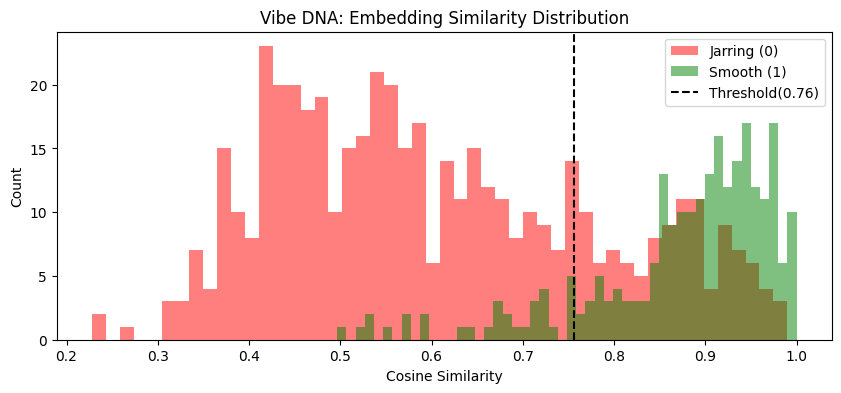

In [171]:
 # PHASE 2 SIAMESE TRAINING - CELL 26 FIXED
 from sklearn.metrics import roc_auc_score, classification_report,precision_recall_curve
 import matplotlib.pyplot as plt

 # 1. Generate Embeddings for the Test Set
 # We use the encoder directly to get the 128-D vectors
 source_embs = encoder.predict(X_test_source)
 target_embs = encoder.predict(X_test_target)

 # 2. Calculate Cosine Similarity as our "Transition Score"
 # Cosine Sim = Dot Product / (norm_A * norm_B). Since they are L2 normalized,it's just the dot product.
 y_proba = np.sum(source_embs * target_embs, axis=1)

 # 3. Find the Optimal Threshold for Class 1 (Smooth) using F1-Optimization
 precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
 f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
 best_threshold = thresholds[np.argmax(f1_scores)]

 # 4. Apply the tuned threshold
 y_pred = (y_proba >= best_threshold).astype(int)

 # 5. Print Results
 roc_auc_val = roc_auc_score(y_test, y_proba)
 print(f"Phase 2 Siamese ROC-AUC: {round(roc_auc_val, 4)}")
 print(f"Optimal Threshold for Vibe Pooling: {round(best_threshold, 4)}")
 print("\n--- Final Tuned Classification Report ---")
 print(classification_report(y_test, y_pred, digits=4))

 # 6. Score summary by label
 score_df = pd.DataFrame({
  "label": y_test,
  "score": y_proba
 })

 print("\nScore summary by label (Cosine Similarity):")
 display(score_df.groupby("label")["score"].describe())

 # 7. Visualize the Separation
 plt.figure(figsize=(10, 4))
 plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='Jarring (0)',
 color='red')
 plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Smooth (1)',
 color='green')
 plt.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold({best_threshold:.2f})')
 plt.title('Vibe DNA: Embedding Similarity Distribution')
 plt.xlabel('Cosine Similarity')
 plt.ylabel('Count')
 plt.legend()
 plt.show()

In [174]:
import json
import os

# 1. Create the models directory
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# 2. Save the Full Model
# Since we used a custom loss function, we save it so it can be re-loaded
model_path = os.path.join(models_dir, "phase2_siamese_contrastive.keras")
siamese_model.save(model_path)

# 3. Save the Encoder separately (This is what you'll use most often)
encoder_path = os.path.join(models_dir, "phase2_encoder_only.keras")
encoder.save(encoder_path)

# 4. Save the Metadata (Threshold and Stats)
# This locks in your 0.7558 threshold for the recommendation engine
metadata = {
 "phase": 2,
 "model_type": "Contrastive_Siamese_1D_CNN",
 "best_threshold": float(best_threshold), # 0.7558
 "roc_auc": float(roc_auc_val),           # 0.8928
 "input_shape": [128, 30],
 "embedding_dim": 128
}

metadata_path = os.path.join(models_dir, "phase2_model_metadata.json")
with open(metadata_path, 'w') as f:
 json.dump(metadata, f, indent=4)

print(f"✅ Full Siamese Model saved: {model_path}")
print(f"✅ Encoder (DNA Generator) saved: {encoder_path}")
print(f"✅ Metadata (Threshold: {best_threshold:.4f}) saved: {metadata_path}")

✅ Full Siamese Model saved: ../models\phase2_siamese_contrastive.keras
✅ Encoder (DNA Generator) saved: ../models\phase2_encoder_only.keras
✅ Metadata (Threshold: 0.7558) saved: ../models\phase2_model_metadata.json
